# Curvas de Aprendizaje: Laboratorio Didáctico de Sobreajuste (Overfitting)

### Propósito del cuaderno
Este cuaderno es un **laboratorio experimental didáctico** para el equipo. Su objetivo es demostrar de forma visual e intuitiva la diferencia matemática entre un modelo que **memoriza** y un modelo que **aprende**, utilizando nuestros **propios datos de transacciones (NLP)**.

### La paradoja del estudiante:
* **Modelo memorión (Overfitting):** Se aprende de memoria los textos exactos de entrenamiento (100% de exactitud), pero fracasa al clasificar descripciones nuevas.
* **Modelo que generaliza:** Entiende los patrones semánticos subyacentes. Su exactitud en entrenamiento es un poco menor, pero aprueba con solidez en los datos reales de prueba.

In [1]:
# =============================================================================
# 1. IMPORTACION DE LIBRERIAS PARA EL LABORATORIO EXPERIMENTAL DE CURVAS
# =============================================================================
import re
import unicodedata
import warnings

# Ignoramos advertencias graficas menores para mantener limpio el entorno educativo
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Componentes de Scikit-Learn:
# - 'TfidfVectorizer': Convierte las descripciones de texto en representaciones matriciales de frecuencias
from sklearn.feature_extraction.text import TfidfVectorizer

# - 'learning_curve': Genera iterativamente evaluaciones con distintos volumenes de datos para trazar curvas de aprendizaje
from sklearn.model_selection import learning_curve

# - 'Pipeline': Une la fase de vectorizacion y el estimador en un unico objeto reproducible
from sklearn.pipeline import Pipeline

# - 'LinearSVC': Maquina de vectores de soporte con hiperplanos lineales, disenada para alta dimension y generalizacion
from sklearn.svm import LinearSVC

# - 'DecisionTreeClassifier': Arbol de decision clasico (utilizado aqui intencionalmente sin podar para provocar sobreajuste)
from sklearn.tree import DecisionTreeClassifier

print("Librerías del laboratorio de diagnóstico cargadas correctamente.")


Librerías del laboratorio de diagnóstico cargadas correctamente.


## 1. Carga y preparación de datos del proyecto
Utilizaremos un subconjunto de nuestro archivo `transacciones.csv`.

In [2]:
# =============================================================================
# 2. CARGA DE MUESTRAS REALES Y FUNCION DE NORMALIZACION
# =============================================================================

def limpiar_texto(texto: str) -> str:
    """
    Aplica el preprocesamiento estandar del proyecto:
    Minusculas, descomposicion de acentos Unicode y eliminacion de caracteres especiales.
    """
    if not isinstance(texto, str):
        return ""
    texto = texto.lower().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()

# Tomamos una muestra estratificada/aleatoria de 3000 registros para que el calculo de validacion cruzada
# se ejecute de forma rapida y fluida en la CPU durante la sesion en vivo con el equipo.
df = pd.read_csv('data/transacciones.csv').sample(3000, random_state=42)
X = df['descripcion'].apply(limpiar_texto)
y = df['categoria']

print(f"Dimensiones de X (Descripciones procesadas): {X.shape}")
print(f"Dimensiones de y (Categorías reales):         {y.shape}")


Dimensiones de X (Descripciones procesadas): (3000,)
Dimensiones de y (Categorías reales):         (3000,)


## 2. Herramienta de diagnóstico: Curvas de aprendizaje (`learning_curve`)

### ¿Cómo se interpreta el gráfico?
* **Eje X (Filas):** Cantidad de datos de entrenamiento suministrados (del 10% al 100%).
* **Eje Y (Accuracy):** Exactitud de la clasificación.
* **Línea Roja (Train):** Rendimiento del modelo sobre los mismos datos con los que estudió.
* **Línea Verde (Validación Cruzada):** Rendimiento del modelo sobre datos nuevos que nunca vio durante esa iteración.

In [3]:
# =============================================================================
# 3. FUNCION EDUCATIVA PARA TRAZAR CURVAS DE APRENDIZAJE
# =============================================================================

def plot_learning_curve(estimator, title, X, y, cv=5):
    """
    Ejecuta validacion cruzada progresiva aumentando la fraccion de datos de entrenamiento
    del 10% al 100% en 5 intervalos equidistantes, graficando las curvas de Train y Validacion.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Ejemplos de Entrenamiento Suministrados (Filas)", fontsize=11)
    plt.ylabel("Puntuación de Exactitud (Accuracy)", fontsize=11)

    # Definimos 5 puntos de evaluacion progresiva: [10%, 32.5%, 55%, 77.5%, 100%]
    train_sizes = np.linspace(0.1, 1.0, 5)
    
    # 'learning_curve' calcula los scores para cada particion y pliegue de validacion cruzada (cv=5)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=-1,              # Utiliza todos los nucleos de CPU disponibles en paralelo
        train_sizes=train_sizes,
        scoring='accuracy'
    )
    
    # Calculamos la media y desviacion estandar a traves de los 5 pliegues para cada tamano de datos
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    # Sombreado de varianza (+/- 1 desviacion estandar) para ver la estabilidad del modelo
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Trazamos las lineas de tendencia
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Puntaje en Entrenamiento (Train)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Puntaje en Validación Cruzada (CV Test)")
    
    plt.legend(loc="lower right", fontsize=10)
    plt.ylim(0.0, 1.05)  # Escala fija de exactitud entre 0% y 105%
    plt.show()


## 3. Experimento 1: El desastre a propósito (Árbol sin restricciones)

### ¿Qué hace el código?
Entrena un `DecisionTreeClassifier(max_depth=None)` conectado a un vectorizador TF-IDF. Al no tener límite de profundidad, el árbol genera ramas infinitas hasta aislar cada palabra y memorizar los extractos.

### Señales de alarma (Red Flags visuales):
* **Línea Roja en 1.0 (100%):** Espejismo de perfección en entrenamiento.
* **Línea Verde muy por debajo:** Desempeño pobre y estancado en datos reales.
* **Brecha abismal (Gap):** Diagnóstico inequívoco de **Sobreajuste severo (Overfitting)**.

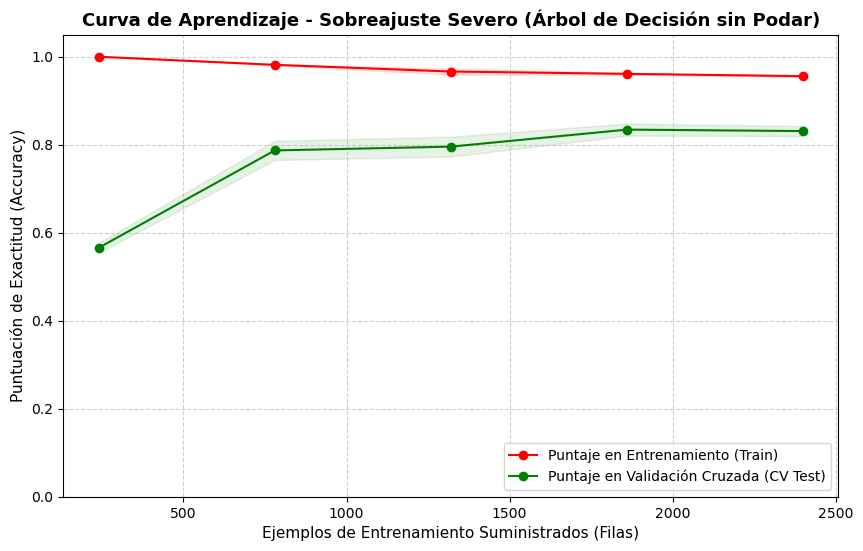

In [4]:
# =============================================================================
# 4. EXPERIMENTO 1: EL MODELO 'MEMORION' (ARBOL SIN RESTRICCIONES - OVERFITTING)
# =============================================================================
# Configuramos un arbol de decision con profundidad infinita (max_depth=None).
# El arbol creara una rama especifica para cada palabra aislada, memorizando el conjunto de estudio.
overfit_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500)),
    ('clf', DecisionTreeClassifier(max_depth=None, random_state=42))
])

# Ejecutamos el trazado: observese la brecha gigante (gap) entre la linea roja (1.0) y la verde
plot_learning_curve(
    overfit_pipeline, 
    "Curva de Aprendizaje - Sobreajuste Severo (Árbol de Decisión sin Podar)", 
    X, y
)


## 4. Experimento 2: El modelo generalizador (LinearSVC)

### ¿Qué hace el código?
Entrena un clasificador `LinearSVC(C=1.0)` utilizado en nuestro entorno productivo. Este algoritmo busca hiperplanos que separan geométricamente las clases con un margen amplio, impidiendo la memorización aislada.

### Señales de aprobación (Green Flags visuales):
* **Convergencia:** La línea de entrenamiento baja ligeramente, perdiendo ese falso 100%, pero la línea de validación sube continuamente a medida que agregamos datos.
* **Brecha estrecha:** Ambas curvas se acercan significativamente. El modelo está entendiendo los patrones subyacentes.

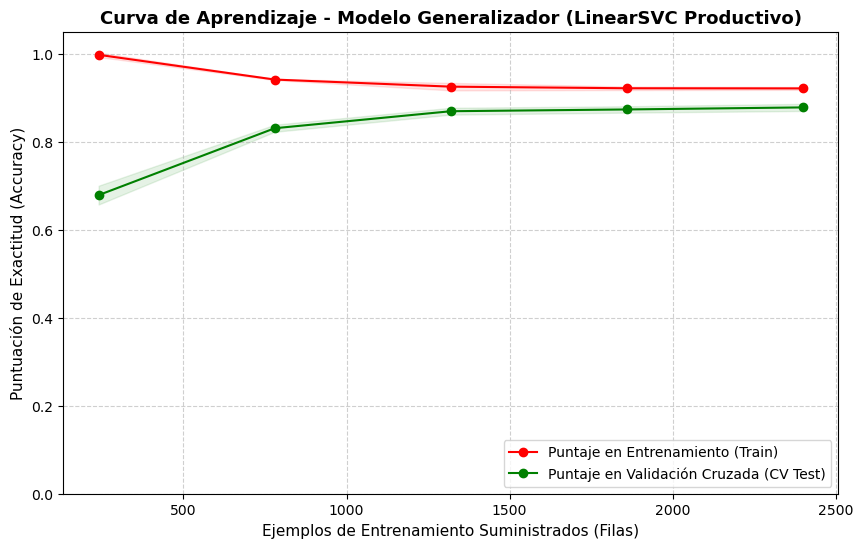

In [5]:
# =============================================================================
# 5. EXPERIMENTO 2: EL MODELO GENERALIZADOR (LINEALSVC PRODUCTIVO)
# =============================================================================
# Configuramos la arquitectura de vectores de soporte con margen lineal regulado (C=1.0).
# LinearSVC maximiza el margen geometrico entre categorias en lugar de memorizar casos individuales.
robust_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500)),
    ('clf', LinearSVC(C=1.0, random_state=42))
])

# Ejecutamos el trazado: observese la convergencia progresiva y la reduccion de la brecha entre curvas
plot_learning_curve(
    robust_pipeline, 
    "Curva de Aprendizaje - Modelo Generalizador (LinearSVC Productivo)", 
    X, y
)
